#### 포지션 예측을 위한 농구 선수의 게임 데이터 정제
 - NBA 농구 선수들의 게임 기록을 데이터로 사용해서 특정 농구 선수의 포지션을 예측

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../Data/basketball.csv')
df.head()       # 여기 컬럼이 다 필요하진 않음. 필요한 컬럼만 뽑는 걸 EDA 라고 함. 필요한 컬럼을 찾는 작업 먼저 함.

,Player,Pos,3P,2P,TRB,AST,STL,BLK
0,Alex Abrines,SG,1.4,0.6,1.3,0.6,0.5,0.1
1,Steven Adams,C,0.0,4.7,7.7,1.1,1.1,1.0
2,Alexis Ajinca,C,0.0,2.3,4.5,0.3,0.5,0.6
3,Chris Andersen,C,0.0,0.8,2.6,0.4,0.4,0.6
4,Will Barton,SG,1.5,3.5,4.3,3.4,0.8,0.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  100 non-null    object 
 1   Pos     100 non-null    object 
 2   3P      100 non-null    float64
 3   2P      100 non-null    float64
 4   TRB     100 non-null    float64
 5   AST     100 non-null    float64
 6   STL     100 non-null    float64
 7   BLK     100 non-null    float64
dtypes: float64(6), object(2)
memory usage: 6.4+ KB


#### Column Description
 - Player : 선수 이름
 - Pos : 포지션(SG, C)
 - 3P : 한 경기당 평균 3점슛 성공 횟수
 - 2P : 한 경기당 평균 2점슛 성공 횟수
 - TRB : 한 경기당 평균 리바운드 성공 횟수
 - AST : 한 경기당 평균 어시스트 성공 횟수
 - STL : 한 경기당 평균 스틸 성공 횟수
 - BLK : 한 경기당 평균 블로킹 성공 횟수

In [4]:
df.Pos.value_counts()   # unique : SG, C 만 나오고, 이거 하면 몇 개 있는지도 나옴

Pos
SG    50
C     50
Name: count, dtype: int64

#### 포지션 별 내용 정리
 - C : Center 는 골대, 포스트 근처에서 슛을 블로킹하고, 리바운드하며, 바깥으로 쳐내며, 골대 근처에서 2점슛으로 득점하기도 한다.
 - SG : Shooting Guard 는 코트 내에서 3점슛 등 장거리 슛을 해서 점수를 얻는 역할을 한다.

#### 데이터 시각화를 통한 EDA(탐색적 데이터 분석) 작업
 : 데이터의 특징을 바탕으로 한 공간에 시각화 함으로써 머신러닝 학습에 필요한 Feature 와 불필요한 Feature 를 쉽게 구분.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns   # seaborn 은 항상 위랑 같이 불러와야 함.
import koreanize_matplotlib  # 한글화

#### 스틸(STL), 2점슛(2P) 데이터 시각화

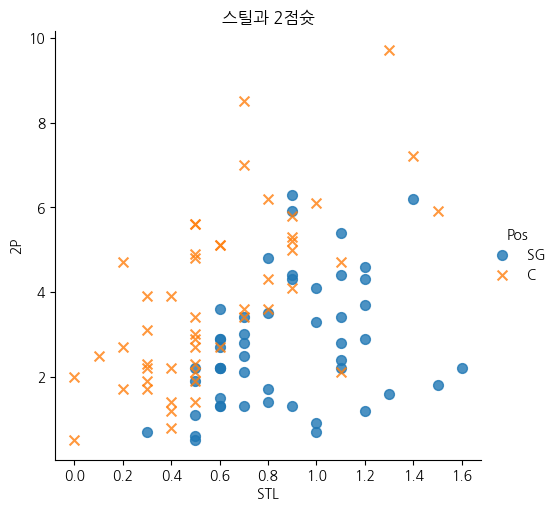

In [10]:
sns.lmplot(
    x='STL',
    y='2P',
    data=df,
    fit_reg=False,     # 회귀선을 사용할건지 (기본값 : True). 데이터의 경향성을 알기 쉬움.
    scatter_kws={'s': 50},   # 좌표상의 점 크기
    hue='Pos',   # 비교할 거
    markers=['o', 'x']
)
plt.title('스틸과 2점슛')
plt.show()

> 스틸과 2점슛의 속성으로 데이터를 분포시킬 경우 SG / C 의 경계가 너무 근접해서 분류하기에 모호하다.
  - 구분하는 법 : 영역을 선을 그어 구분해볼 때 복잡하면 모호한 거고, 선 위주면 괜찮음.

#### 어시스트와 2점슛 데이터 시각화

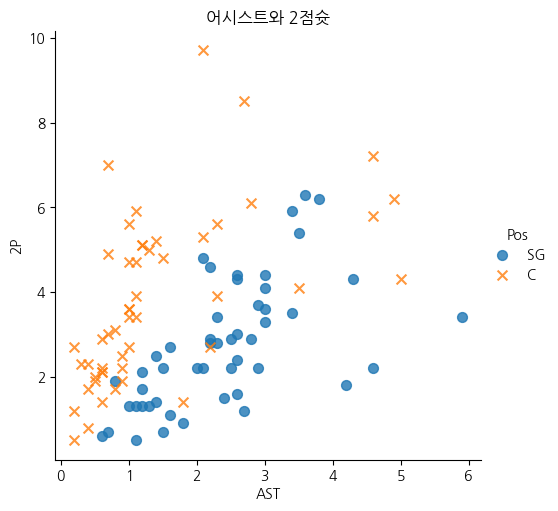

In [12]:
sns.lmplot(
    x='AST',
    y='2P',
    data=df,
    fit_reg=False,     # 회귀를 사용할건지 (기본값 : True)
    scatter_kws={'s': 50},   # 좌표상의 점 크기
    hue='Pos',   # 비교할 거
    markers=['o', 'x']
)
plt.title('어시스트와 2점슛')
plt.show()

> 어시스트와 2점슛의 속성으로 데이터를 분포시킬 경우 SG / C 의 경계가 너무 근접해서 분류하기에 모호하다. (하지만, 이전의 스틸과 2점슛보단 나은편)

#### 블로킹과 3점슛의 데이터 시각화

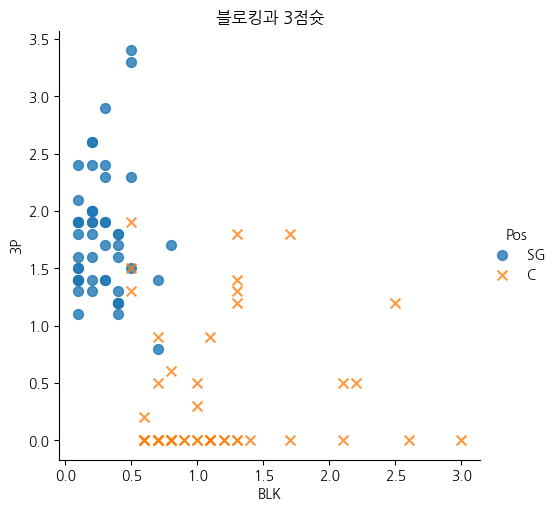

In [16]:
sns.lmplot(
    x='BLK',
    y='3P',
    data=df,
    fit_reg=False,     # 회귀를 사용할건지 (기본값 : True)
    scatter_kws={'s': 50},   # 좌표상의 점 크기
    hue='Pos',   # 비교할 거
    markers=['o', 'x']
)
plt.title('블로킹과 3점슛')
plt.show()

#### 리바운드와 3점슛의 데이터 시각화

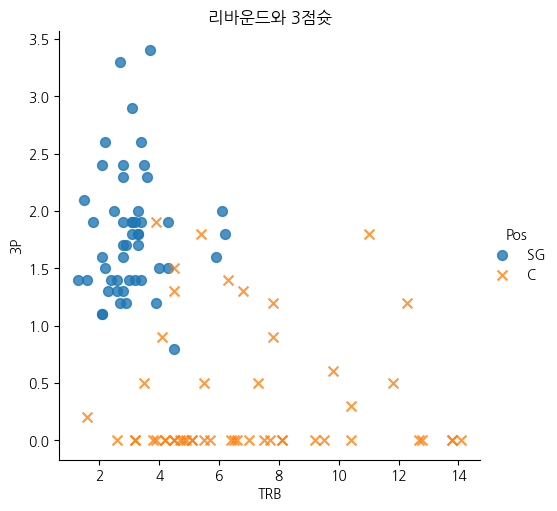

In [17]:
sns.lmplot(
    x='TRB',
    y='3P',
    data=df,
    fit_reg=False,     # 회귀를 사용할건지 (기본값 : True)
    scatter_kws={'s': 50},   # 좌표상의 점 크기
    hue='Pos',   # 비교할 거
    markers=['o', 'x']
)
plt.title('리바운드와 3점슛')
plt.show()

> EBA(Explorary Data Analysis : 탐색적 데이터 분석) 결과
 분별력이 없는 Feature 를 데이터에서 제거하기 위해 시각화를 해본 결과,
 2P, AST, STL 은 분별력이 없는 것으로 판단됨.

In [19]:
df.head()

,Player,Pos,3P,2P,TRB,AST,STL,BLK
0,Alex Abrines,SG,1.4,0.6,1.3,0.6,0.5,0.1
1,Steven Adams,C,0.0,4.7,7.7,1.1,1.1,1.0
2,Alexis Ajinca,C,0.0,2.3,4.5,0.3,0.5,0.6
3,Chris Andersen,C,0.0,0.8,2.6,0.4,0.4,0.6
4,Will Barton,SG,1.5,3.5,4.3,3.4,0.8,0.5


In [21]:
# 분별력이 없는 Feature 를 데이터에서 제거
df.drop(
    ['2P', 'AST', 'STL'],
    axis='columns',    # 혹은 axis = 1
    inplace=True
)
df.head()

,Player,Pos,3P,TRB,BLK
0,Alex Abrines,SG,1.4,1.3,0.1
1,Steven Adams,C,0.0,7.7,1.0
2,Alexis Ajinca,C,0.0,4.5,0.6
3,Chris Andersen,C,0.0,2.6,0.6
4,Will Barton,SG,1.5,4.3,0.5


----
#### 학습데이터와 테스트데이터로 나누기

In [20]:
from sklearn.model_selection import train_test_split

In [23]:
# 다듬어진 데이터에서 20%를 테스트 데이터로 분류. 원래 트레인 70% 정도 하지만, 지금 데이터 양이 100개로 적으므로 트레인 비율을 80% 로 늘리는 게 좋음.
train, test = \
    train_test_split(
        df,
        random_state=42,
        stratify=df.Pos,
        test_size=0.2    # 테스트 데이터 비율 지정
    )

In [25]:
# 데이터 갯수 확인 작업
print(train.shape, test.shape)

(80, 5) (20, 5)


In [26]:
train.head()

,Player,Pos,3P,TRB,BLK
31,Pau Gasol,C,0.9,7.8,1.1
5,Nicolas Batum,SG,1.8,6.2,0.4
19,Allen Crabbe,SG,1.7,2.9,0.3
32,Manu Ginobili,SG,1.3,2.3,0.2
36,Danny Green,SG,1.7,3.3,0.8


In [28]:
test.head()

,Player,Pos,3P,TRB,BLK
13,Avery Bradley,SG,2.0,6.1,0.2
58,Zach LaVine,SG,2.6,3.4,0.2
22,Troy Daniels,SG,2.1,1.5,0.1
4,Will Barton,SG,1.5,4.3,0.5
16,Willie Cauley-Stein,C,0.0,4.5,0.6


In [29]:
# 데이터 저장하기
train.to_csv('../Data/basketball_train.csv', index=None)   # 인덱스도 저장되기에 제외시킴
test.to_csv('../Data/basketball_test.csv', index=None)